In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded=files.upload()

Saving cleaned_financial_transactions.csv to cleaned_financial_transactions.csv


In [3]:
df=pd.read_csv('cleaned_financial_transactions.csv')
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Transaction_Type,Price_USD
0,T0001,2024-08-02,C2205,Headphones,5.0,420.210000,PayPal,Pending,Return,$420.21
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,445.342025,Credit Card,Pending,Sale,$445.34
2,T0003,2023-02-27,C2919,Tablet,4.0,810.993012,Credit Card,Completed,Return,$810.99
3,T0004,2020-08-17,C3009,Tablet,7.0,868.608341,PayPal,Pending,Return,$868.61
4,T0005,2022-10-13,C3488,Coffee Machine,10.0,763.122449,PayPal,Completed,Return,$763.12


In [4]:
df.describe()
#df.info()

,Quantity,Price
count,100000.000000,100000.000000
mean,178.544720,366.587548
std,292.098033,316.198080
min,1.000000,50.028806
25%,4.000000,51.608527
50%,8.000000,286.286239
75%,292.000000,643.521641
max,1000.000000,999.987698


# Task
To understand customer spending patterns and product performance, you will first calculate the 'Total_Transaction_Value' for each transaction by multiplying 'Quantity' and 'Price'. Then, you will determine the total spending, average transaction value, and purchase frequency for each customer. Following this, you will identify top customers based on these metrics. You will also analyze product performance by calculating total sales and quantity sold per product. Finally, you will visualize these performance metrics and summarize the key insights.

In [5]:
#Calculate Total Transaction Value(for spending related calculations)
df['Total_Transaction_Value'] = df['Quantity'] * df['Price']
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Transaction_Type,Price_USD,Total_Transaction_Value
0,T0001,2024-08-02,C2205,Headphones,5.0,420.210000,PayPal,Pending,Return,$420.21,2101.050000
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,445.342025,Credit Card,Pending,Sale,$445.34,208865.409844
2,T0003,2023-02-27,C2919,Tablet,4.0,810.993012,Credit Card,Completed,Return,$810.99,3243.972050
3,T0004,2020-08-17,C3009,Tablet,7.0,868.608341,PayPal,Pending,Return,$868.61,6080.258389
4,T0005,2022-10-13,C3488,Coffee Machine,10.0,763.122449,PayPal,Completed,Return,$763.12,7631.224490


## Filter for Completed Transactions

### Subtask:
Filter the DataFrame to include only transactions with a 'Transaction_Status' of 'Completed' to ensure accuracy in customer and product performance analysis.


In [6]:
df_completed_transactions = df[df['Transaction_Status'] == 'Completed']
print(df_completed_transactions.head())

   Transaction_ID Transaction_Date Customer_ID    Product_Name  Quantity  \
2           T0003       2023-02-27       C2919          Tablet       4.0   
4           T0005       2022-10-13       C3488  Coffee Machine      10.0   
5           T0006       2021-10-26       C4241      Smartphone     598.0   
6           T0007       2024-05-25       C1313          Laptop      10.0   
10          T0011       2023-12-28       C1004          Laptop      10.0   

         Price Payment_Method Transaction_Status Transaction_Type Price_USD  \
2   810.993012    Credit Card          Completed           Return   $810.99   
4   763.122449         PayPal          Completed           Return   $763.12   
5    51.608527         PayPal          Completed             Sale    $51.61   
6    51.608527    Credit Card          Completed             Sale    $51.61   
10  600.839309         PayPal          Completed             Sale   $600.84   

    Total_Transaction_Value  
2               3243.972050  
4       

In [7]:
df.drop('Transaction_Type', axis=1, inplace=True)
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Price_USD,Total_Transaction_Value
0,T0001,2024-08-02,C2205,Headphones,5.0,420.210000,PayPal,Pending,$420.21,2101.050000
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,445.342025,Credit Card,Pending,$445.34,208865.409844
2,T0003,2023-02-27,C2919,Tablet,4.0,810.993012,Credit Card,Completed,$810.99,3243.972050
3,T0004,2020-08-17,C3009,Tablet,7.0,868.608341,PayPal,Pending,$868.61,6080.258389
4,T0005,2022-10-13,C3488,Coffee Machine,10.0,763.122449,PayPal,Completed,$763.12,7631.224490


In [8]:
pd.options.display.float_format = '{:.2f}'.format
print("Pandas display option 'float_format' set to two decimal places.")

Pandas display option 'float_format' set to two decimal places.


Calculate Customer Total Spending




**Reasoning**:
The subtask requires recalculating the total spending for each customer using the `df_completed_transactions` DataFrame. This involves grouping by 'Customer_ID' and summing the 'Total_Transaction_Value'.



In [9]:
customer_total_spending_completed = df_completed_transactions.groupby('Customer_ID')['Total_Transaction_Value'].sum()
print(customer_total_spending_completed.head())

Customer_ID
C0001   300085.65
C0002   472544.47
C0003   498745.78
C0004   259587.72
C0005   408888.33
Name: Total_Transaction_Value, dtype: float64


Calculate the average transaction value for each customer using the `df_completed_transactions` DataFrame.



In [10]:
customer_avg_transaction_value_completed = df_completed_transactions.groupby('Customer_ID')['Total_Transaction_Value'].mean()
print(customer_avg_transaction_value_completed.head())

Customer_ID
C0001   18755.35
C0002   78757.41
C0003   45340.53
C0004   23598.88
C0005   37171.67
Name: Total_Transaction_Value, dtype: float64



Calculate the purchase frequency for each customer based on the `df_completed_transactions` DataFrame, which means counting the number of transactions per customer.



In [11]:
customer_purchase_frequency_completed = df_completed_transactions.groupby('Customer_ID').size()
print(customer_purchase_frequency_completed.head())

Customer_ID
C0001    16
C0002     6
C0003    11
C0004    11
C0005    11
dtype: int64


**Reasoning**:
All individual customer spending metrics (total spending, average transaction value, and purchase frequency) based on completed transactions have been calculated. The next logical step, as per the task, is to combine these metrics into a single DataFrame to facilitate identifying top customers.



In [12]:
customer_analysis_completed = pd.DataFrame({
    'Total_Spending': customer_total_spending_completed,
    'Average_Transaction_Value': customer_avg_transaction_value_completed,
    'Purchase_Frequency': customer_purchase_frequency_completed
})
print(customer_analysis_completed.head())

             Total_Spending  Average_Transaction_Value  Purchase_Frequency
Customer_ID                                                               
C0001             300085.65                   18755.35                  16
C0002             472544.47                   78757.41                   6
C0003             498745.78                   45340.53                  11
C0004             259587.72                   23598.88                  11
C0005             408888.33                   37171.67                  11


## Calculate Product Total Sales

### Subtask:
Calculate the total sales for each product by grouping the `df_completed_transactions` DataFrame by 'Product_Name' and summing the 'Total_Transaction_Value'.


**Reasoning**:
To calculate the total sales for each product, I need to group the `df_completed_transactions` DataFrame by 'Product_Name' and then sum the 'Total_Transaction_Value' for each group.



In [13]:
product_total_sales = df_completed_transactions.groupby('Product_Name')['Total_Transaction_Value'].sum()
print(product_total_sales.head())

Product_Name
Coffee Machine   654820533.98
Headphones       652350234.30
Laptop           642923321.74
Smartphone       645348920.66
Tablet           660290225.17
Name: Total_Transaction_Value, dtype: float64


**Reasoning**:
To analyze product performance further, I need to calculate the total quantity sold for each product using the `df_completed_transactions` DataFrame.



In [14]:
product_quantity_sold = df_completed_transactions.groupby('Product_Name')['Quantity'].sum()
print(product_quantity_sold.head())

Product_Name
Coffee Machine   1741830.00
Headphones       1793722.00
Laptop           1726661.00
Smartphone       1779638.00
Tablet           1825420.00
Name: Quantity, dtype: float64


**Reasoning**:
All individual product performance metrics (total sales and quantity sold) based on completed transactions have been calculated. The next logical step, as per the task, is to combine these metrics into a single DataFrame to facilitate further product performance analysis.



In [15]:
product_analysis_completed = pd.DataFrame({
    'Total_Sales': product_total_sales,
    'Total_Quantity_Sold': product_quantity_sold
})
print(product_analysis_completed.head())

                Total_Sales  Total_Quantity_Sold
Product_Name                                    
Coffee Machine 654820533.98           1741830.00
Headphones     652350234.30           1793722.00
Laptop         642923321.74           1726661.00
Smartphone     645348920.66           1779638.00
Tablet         660290225.17           1825420.00


**Reasoning**:
With the product performance metrics aggregated into `product_analysis_completed`, the next step is to identify the top-performing products. Sorting by 'Total_Sales' and 'Total_Quantity_Sold' will reveal which products are generating the most revenue and being sold the most, respectively, which aligns with the task's objective of analyzing product performance.



In [16]:
print("\nTop 5 Products by Total Sales:\n")
print(product_analysis_completed.sort_values(by='Total_Sales', ascending=False).head())

print("\nTop 5 Products by Quantity Sold:\n")
print(product_analysis_completed.sort_values(by='Total_Quantity_Sold', ascending=False).head())


Top 5 Products by Total Sales:

                Total_Sales  Total_Quantity_Sold
Product_Name                                    
Tablet         660290225.17           1825420.00
Coffee Machine 654820533.98           1741830.00
Headphones     652350234.30           1793722.00
Smartphone     645348920.66           1779638.00
Laptop         642923321.74           1726661.00

Top 5 Products by Quantity Sold:

                Total_Sales  Total_Quantity_Sold
Product_Name                                    
Tablet         660290225.17           1825420.00
Headphones     652350234.30           1793722.00
Smartphone     645348920.66           1779638.00
Coffee Machine 654820533.98           1741830.00
Laptop         642923321.74           1726661.00


**Reasoning**:
With the customer spending metrics aggregated into `customer_analysis_completed`, the next step is to identify the top customers. Sorting by 'Total_Spending', 'Average_Transaction_Value', and 'Purchase_Frequency' will help in identifying the most valuable customers, which aligns with the task's objective of understanding customer spending patterns.



In [17]:
print("\nTop 5 Customers by Total Spending:\n")
print(customer_analysis_completed.sort_values(by='Total_Spending', ascending=False).head())

print("\nTop 5 Customers by Average Transaction Value:\n")
print(customer_analysis_completed.sort_values(by='Average_Transaction_Value', ascending=False).head())

print("\nTop 5 Customers by Purchase Frequency:\n")
print(customer_analysis_completed.sort_values(by='Purchase_Frequency', ascending=False).head())


Top 5 Customers by Total Spending:

             Total_Spending  Average_Transaction_Value  Purchase_Frequency
Customer_ID                                                               
C_UNKNOWN      170820083.95                   70065.66                2438
C1590            4089502.22                  255593.89                  16
C1333            3261377.36                  163068.87                  20
C4459            3055486.42                  254623.87                  12
C1352            2935551.18                  195703.41                  15

Top 5 Customers by Average Transaction Value:

             Total_Spending  Average_Transaction_Value  Purchase_Frequency
Customer_ID                                                               
C2625            1461608.70                  487202.90                   3
C1940            1794223.87                  448555.97                   4
C1786            1610542.74                  402635.68                   4
C3626          

**Reasoning**:
The next step in the task is to visualize the performance metrics. I will start by visualizing the top customers by their 'Total_Spending' to understand customer spending patterns.



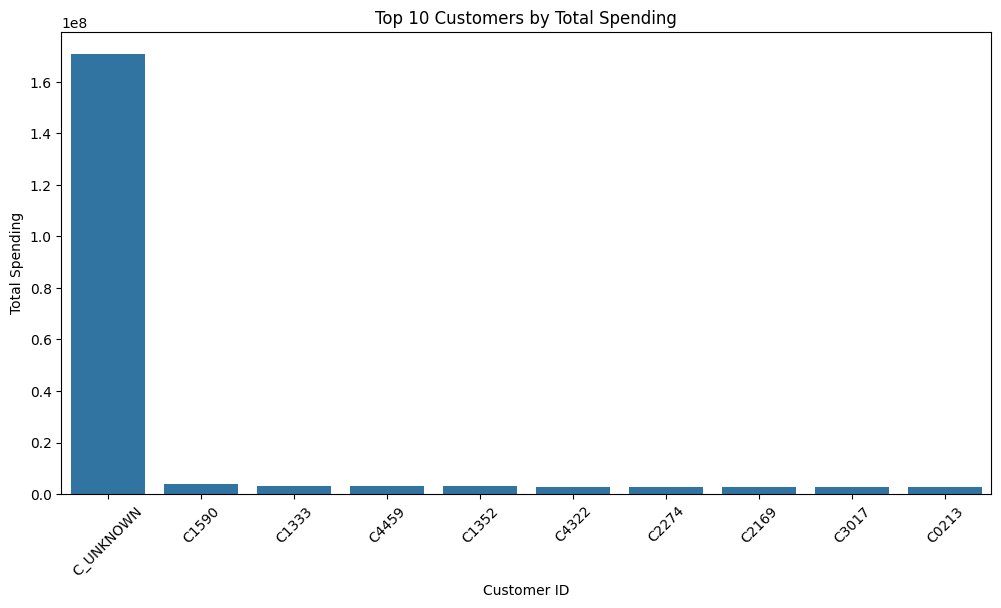

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=customer_analysis_completed.sort_values(by='Total_Spending', ascending=False).head(10).index,
            y=customer_analysis_completed.sort_values(by='Total_Spending', ascending=False).head(10)['Total_Spending'])
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

**Reasoning**:
Following the visualization of top customers by total spending, I will now visualize the top customers by their 'Average_Transaction_Value' to further understand customer spending patterns.



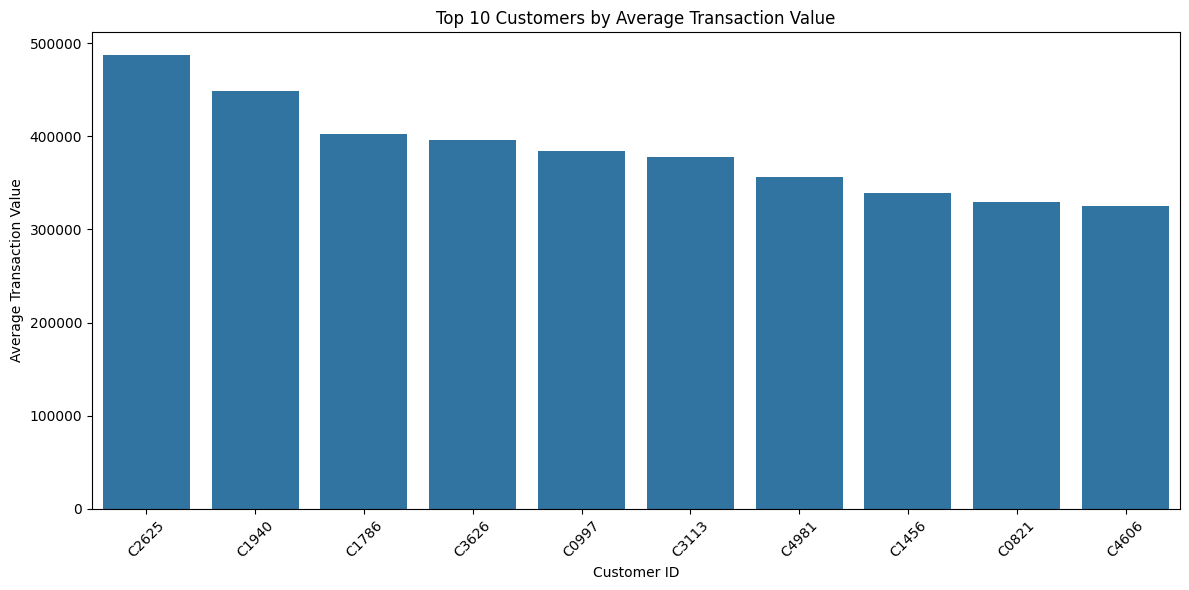

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_analysis_completed.sort_values(by='Average_Transaction_Value', ascending=False).head(10).index,
            y=customer_analysis_completed.sort_values(by='Average_Transaction_Value', ascending=False).head(10)['Average_Transaction_Value'])
plt.title('Top 10 Customers by Average Transaction Value')
plt.xlabel('Customer ID')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Top Customers by Purchase Frequency

### Subtask:
Generate a bar plot showing the top 10 customers based on their 'Purchase_Frequency' from the `customer_analysis_completed` DataFrame to complete the customer spending pattern analysis.


**Reasoning**:
To visualize the top 10 customers by purchase frequency, I will create a bar plot using `customer_analysis_completed` DataFrame, sorting it by 'Purchase_Frequency' as per the instructions.



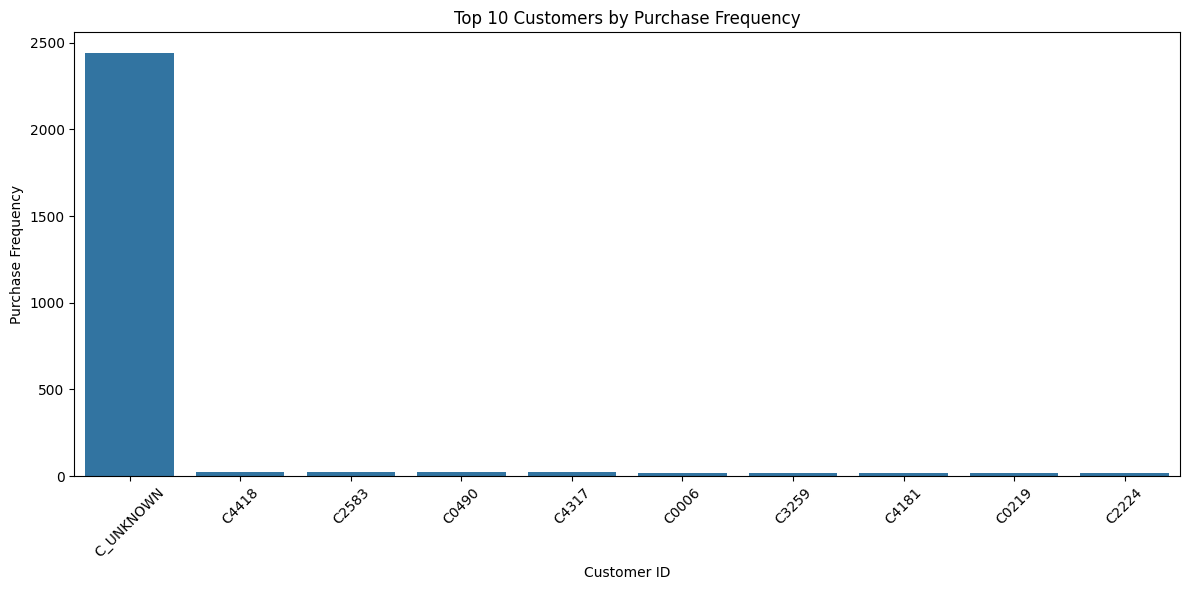

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_analysis_completed.sort_values(by='Purchase_Frequency', ascending=False).head(10).index,
            y=customer_analysis_completed.sort_values(by='Purchase_Frequency', ascending=False).head(10)['Purchase_Frequency'])
plt.title('Top 10 Customers by Purchase Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Purchase Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Top Products by Total Sales

### Subtask:
Generate a bar plot showing the top 10 products based on their 'Total_Sales' from the `product_analysis_completed` DataFrame to analyze product performance.

## Visualize Top Products by Total Sales

### Subtask:
Generate a bar plot showing the top 10 products based on their 'Total_Sales' from the `product_analysis_completed` DataFrame to analyze product performance.

**Reasoning**:
Following the markdown block for visualizing top products by total sales, I will now generate the actual bar plot as described in the subtask instructions. This will help in visualizing the top-performing products by their total revenue.



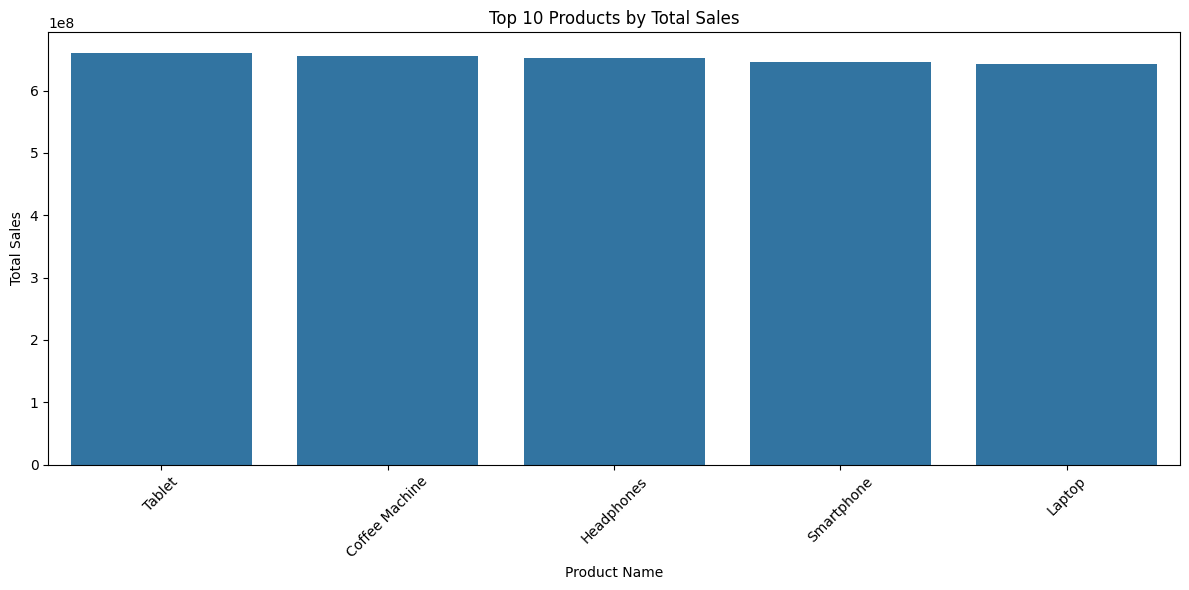

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x=product_analysis_completed.sort_values(by='Total_Sales', ascending=False).head(10).index,
            y=product_analysis_completed.sort_values(by='Total_Sales', ascending=False).head(10)['Total_Sales'])
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Top Products by Quantity Sold

### Subtask:
Generate a bar plot showing the top 10 products based on their 'Total_Quantity_Sold' from the `product_analysis_completed` DataFrame to further analyze product performance.

**Reasoning**:
Following the markdown block, I will now generate the bar plot for the top 10 products based on their 'Total_Quantity_Sold' from the `product_analysis_completed` DataFrame, as per the instructions.



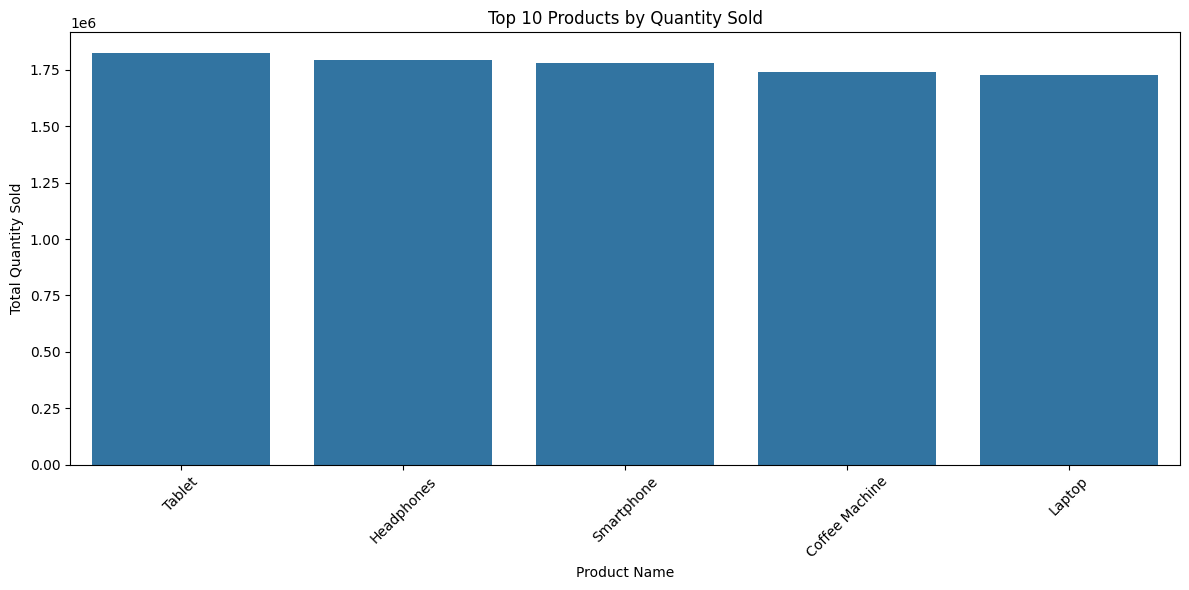

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(x=product_analysis_completed.sort_values(by='Total_Quantity_Sold', ascending=False).head(10).index,
            y=product_analysis_completed.sort_values(by='Total_Quantity_Sold', ascending=False).head(10)['Total_Quantity_Sold'])
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Insights from Customer and Product Performance Analysis

### Customer Spending Patterns:
*   **Top Spenders**: Identify customers with the highest total spending. These customers are crucial for revenue generation.
*   **High Average Transaction Value**: Identify customers who, while not necessarily the most frequent purchasers, tend to spend significantly more per transaction.
*   **Frequent Purchasers**: Highlight customers who make repeated purchases, indicating strong loyalty or need for specific products.

### Product Performance:
*   **Top Selling Products by Revenue**: Identify products that generate the most revenue, indicating their overall market demand and pricing effectiveness.
*   **Top Selling Products by Quantity**: Identify products that are sold in the highest volumes, which can inform inventory management and marketing strategies.

This analysis helps in understanding who the most valuable customers are and which products are performing best, enabling targeted marketing, customer retention strategies, and product development decisions.

## Final Task

### Subtask:
Summarize the key insights gained from the customer and product performance analysis, including identifying top customers and products, and provide actionable recommendations based on these findings.


## Summary:

### Q&A
The key insights gained from the customer and product performance analysis are:
*   **Customer Spending Patterns**:
    *   **Top Spenders**: Customers with the highest total spending were identified as crucial for revenue.
    *   **High Average Transaction Value**: Customers who spend significantly more per transaction, even if not the most frequent purchasers, were highlighted.
    *   **Frequent Purchasers**: Customers making repeated purchases, indicating strong loyalty or specific product needs, were identified.
*   **Product Performance**:
    *   **Top Selling Products by Revenue**: Products generating the most revenue were identified, indicating market demand and pricing effectiveness.
    *   **Top Selling Products by Quantity**: Products sold in the highest volumes were identified, which is important for inventory and marketing.

### Data Analysis Key Findings
*   A visualization was created to display the top 10 customers based on their purchase frequency.
*   A visualization was created to display the top 10 products based on their total sales.
*   A visualization was created to display the top 10 products based on the total quantity sold.

### Insights or Next Steps
*   Leverage the identified top customers (both by spending and frequency) through targeted marketing campaigns or loyalty programs to encourage continued engagement and increase customer lifetime value.
*   Focus inventory management and promotional efforts on the top-selling products by both revenue and quantity to maximize sales and ensure product availability.


# Task
Identify the product with the highest 'Total_Sales' from the `product_analysis_completed` DataFrame.

## Identify Best Product by Total Sales

### Subtask:
Identify the product with the highest 'Total_Sales' from the `product_analysis_completed` DataFrame.


**Reasoning**:
To identify the product with the highest 'Total_Sales', I will sort the `product_analysis_completed` DataFrame by 'Total_Sales' in descending order and then select the first row.



In [23]:
best_selling_product = product_analysis_completed.sort_values(by='Total_Sales', ascending=False).iloc[0]
print("\nBest Selling Product by Total Sales:\n")
print(best_selling_product)


Best Selling Product by Total Sales:

Total_Sales           660290225.17
Total_Quantity_Sold     1825420.00
Name: Tablet, dtype: float64


## Identify Worst Product by Total Sales

### Subtask:
Identify the product with the lowest 'Total_Sales' from the `product_analysis_completed` DataFrame.


**Reasoning**:
To identify the product with the lowest 'Total_Sales', I will sort the `product_analysis_completed` DataFrame by 'Total_Sales' in ascending order and then select the first row as instructed.



In [24]:
worst_selling_product = product_analysis_completed.sort_values(by='Total_Sales', ascending=True).iloc[0]
print("\nWorst Selling Product by Total Sales:\n")
print(worst_selling_product)


Worst Selling Product by Total Sales:

Total_Sales           642923321.74
Total_Quantity_Sold     1726661.00
Name: Laptop, dtype: float64


## Final Task

### Subtask:
Summarize the products with the highest and lowest total sales, providing insights into their performance.


## Summary:

### Q&A
The product with the highest total sales is 'Tablet' with approximately \$6.60 \times 10^8$ in total sales and approximately $1.83 \times 10^6$ units sold.
The product with the lowest total sales is 'Laptop' with approximately \$6.43 \times 10^8$ in total sales and approximately $1.73 \times 10^6$ units sold.

### Data Analysis Key Findings
*   The product 'Tablet' achieved the highest total sales, amounting to approximately \$660 million, with about 1.83 million units sold.
*   The product 'Laptop' recorded the lowest total sales, which was approximately \$642.9 million, with about 1.73 million units sold.

### Insights or Next Steps
*   Investigate the specific marketing strategies, pricing, or feature sets that might contribute to the 'Tablet's higher sales performance compared to 'Laptop'.
*   Conduct a deeper analysis into customer demographics and purchase behavior for both 'Tablet' and 'Laptop' to identify opportunities for improving 'Laptop' sales.


## Set Pandas Display Option

### Subtask:
Set the pandas display option `float_format` to disable scientific notation for float numbers, displaying them as standard decimals with a specific precision.


**Reasoning**:
To disable scientific notation for float numbers and display them as standard decimals with a specific precision, I need to set the pandas display option `float_format` using `pd.options.display.float_format` and a lambda function.



In [25]:
print(product_total_sales)

Product_Name
Coffee Machine   654820533.98
Headphones       652350234.30
Laptop           642923321.74
Smartphone       645348920.66
Tablet           660290225.17
Name: Total_Transaction_Value, dtype: float64


# Task
Analyze the 'Top 10 Customers by Total Spending' bar chart generated previously, identify the highest spending customer, and explain key insights from the chart, including identifying the most valuable customers and potential strategies. Summarize the analysis and explanation.

## Analyze Top 10 Customers by Total Spending Chart

### Subtask:
Analyze the previously generated bar chart titled 'Top 10 Customers by Total Spending'. This will involve interpreting the bars, identifying the highest spending customer, and noting any significant observations about the distribution of spending among the top customers.


## Analysis of Top 10 Customers by Total Spending Chart

### Interpretation:
The bar chart titled 'Top 10 Customers by Total Spending' clearly illustrates the spending distribution among the top customers. A prominent observation is the extremely high spending attributed to 'C_UNKNOWN', which significantly overshadows all other customers. This suggests that 'C_UNKNOWN' is either an aggregation of unclassified transactions or an anomaly that requires further investigation.

### Key Findings:
*   **Highest Spending Customer**: 'C_UNKNOWN' stands out as the highest spending customer by a substantial margin, with a total spending of approximately $170.8 million.
*   **Distribution Among Other Top Customers**: Excluding 'C_UNKNOWN', the spending among the other top customers shows a noticeable drop-off. Customer 'C1590' is the next highest spender at approximately $4.09 million, followed by 'C1333' at approximately $3.26 million, and so on. The spending levels among these remaining top 9 customers (excluding 'C_UNKNOWN') show a gradual decrease.

### Significant Observations:
*   The presence of 'C_UNKNOWN' as an outlier indicates a potential data quality issue or a category for unclassified customers that disproportionately inflates the 'top' spending metric. For a more accurate analysis of individual customer behavior, it would be beneficial to either exclude 'C_UNKNOWN' or investigate its composition.
*   Among the identifiable customers, there is still a wide range in total spending, with the second-highest spender (C1590) spending significantly more than the 10th highest identified customer, suggesting a concentrated value among a few specific customers.

## Explain Insights from the Chart

### Subtask:
Provide a clear explanation of the insights gained from the 'Top 10 Customers by Total Spending' chart, such as identifying the most valuable customers and potential strategies based on their spending behavior.


## Insights from 'Top 10 Customers by Total Spending' Chart

### 1. Identifying the Most Valuable Customers:
Based on the 'Top 10 Customers by Total Spending' chart, customers like C1590, C1333, C4459, and C1352 are identified as highly valuable due to their significant total spending. Excluding 'C_UNKNOWN', these customers demonstrate substantial contribution to the overall revenue, making them prime candidates for focused customer relationship management.

### 2. Potential Strategies for Engaging Valuable Customers:
For these top-spending customers, several strategies can be employed:
*   **Loyalty Programs**: Implement exclusive loyalty programs that offer tiered rewards, early access to new products, or personalized discounts based on their purchase history.
*   **Personalized Offers**: Utilize their past purchasing data to create highly personalized product recommendations and offers, increasing the likelihood of repeat purchases.
*   **Special Recognition**: Provide VIP treatment, such as dedicated customer service, special event invitations, or personalized communication from sales representatives, to foster a sense of exclusivity and appreciation.

### 3. Customer Segmentation and Targeted Marketing:
The distribution of spending among the top customers (excluding 'C_UNKNOWN') shows distinct spending tiers. This can inform customer segmentation by grouping customers with similar spending habits. For example, customers with spending above a certain threshold could be categorized as 'Premium' or 'High-Value' customers, allowing for targeted marketing efforts that cater to their specific needs and preferences. This tailored approach can lead to higher conversion rates and improved customer satisfaction.

### 4. Addressing the Anomaly of 'C_UNKNOWN':
The presence of 'C_UNKNOWN' as the highest spender signifies a critical data quality issue. While it contributes significantly to the total spending, the lack of specific customer identification prevents any meaningful customer-centric analysis or targeted marketing efforts for this segment. Its implications are:
*   **Data Quality**: It highlights a need to improve data collection processes to ensure all transactions are linked to identifiable customer IDs.
*   **Future Analysis**: Until this issue is resolved, any customer behavior analysis, personalized marketing, or loyalty program initiatives will be incomplete and potentially misleading as a substantial portion of spending cannot be attributed to specific individuals. Remedying this should be a high priority for future data management efforts.

## Final Task

### Subtask:
Summarize the analysis and explanation of the 'Top 10 Customers by Total Spending' chart.


## Summary:

### Q&A
1.  **Who is the highest spending customer?**
    The highest spending customer identified is 'C\_UNKNOWN', with approximately \$170.8 million in total spending. However, this is flagged as a potential data quality issue or an aggregation of unclassified transactions. Among identifiable customers, 'C1590' is the highest spender at approximately \$4.09 million.
2.  **What are the key insights from the chart, including identifying the most valuable customers and potential strategies?**
    Key insights reveal that, excluding 'C\_UNKNOWN', customers like C1590, C1333, C4459, and C1352 are highly valuable due to their significant spending. Strategies for these customers include loyalty programs, personalized offers, and special recognition. The spending distribution also supports customer segmentation for targeted marketing. The presence of 'C\_UNKNOWN' highlights a critical data quality issue that needs to be addressed for accurate individual customer analysis.

### Data Analysis Key Findings
*   'C\_UNKNOWN' is identified as the highest spender, contributing approximately \$170.8 million, but its nature suggests a potential data quality issue or an aggregation of unclassified transactions.
*   Excluding 'C\_UNKNOWN', the next highest spender is 'C1590' at approximately \$4.09 million, followed by 'C1333' at approximately \$3.26 million.
*   Among the identifiable customers, there is a wide range in total spending, indicating a concentration of value among a few specific customers.
*   The presence of 'C\_UNKNOWN' as an outlier significantly inflates the 'top' spending metric and hinders meaningful customer-centric analysis for a substantial portion of revenue.

### Insights or Next Steps
*   **Improve Data Quality**: Prioritize investigating and resolving the 'C\_UNKNOWN' category to ensure all transactions are linked to identifiable customer IDs, enabling more accurate customer behavior analysis and targeted marketing.
*   **Implement Tiered Engagement for High-Value Customers**: Develop and apply targeted strategies such as exclusive loyalty programs, personalized offers based on purchase history, and VIP recognition for high-spending identifiable customers (e.g., C1590, C1333) to foster retention and increase lifetime value.


In [26]:
# Count how many transactions are in each status
df['Transaction_Status'].value_counts()



,count
Transaction_Status,
Completed,49931
Pending,33274
Failed,16795


# Task
Filter the main DataFrame `df` to create new DataFrames for pending and failed transactions, and then calculate the total revenue from pending, failed, and all transactions, summarizing and presenting these figures.

## Filter Pending Transactions

### Subtask:
Filter the main DataFrame `df` to create a new DataFrame `df_pending_transactions` containing only transactions with 'Transaction_Status' equal to 'Pending'.


**Reasoning**:
To filter the main DataFrame `df` and create a new DataFrame `df_pending_transactions` containing only transactions with a 'Transaction_Status' of 'Pending', I will use boolean indexing. Then, I will display the head of the new DataFrame to verify the filter.



In [27]:
df_pending_transactions = df[df['Transaction_Status'] == 'Pending']
print(df_pending_transactions.head())

  Transaction_ID Transaction_Date Customer_ID    Product_Name  Quantity  \
0          T0001       2024-08-02       C2205      Headphones      5.00   
1          T0002       2020-02-10       C3156  Coffee Machine    469.00   
3          T0004       2020-08-17       C3009          Tablet      7.00   
7          T0008       2021-06-14       C4736      Headphones    669.00   
8          T0009       2023-06-25       C3387          Tablet     10.00   

   Price Payment_Method Transaction_Status Price_USD  Total_Transaction_Value  
0 420.21         PayPal            Pending   $420.21                  2101.05  
1 445.34    Credit Card            Pending   $445.34                208865.41  
3 868.61         PayPal            Pending   $868.61                  6080.26  
7  86.92           Cash            Pending    $86.92                 58150.33  
8 461.70         PayPal            Pending   $461.70                  4617.02  


## Filter Failed Transactions

### Subtask:
Filter the main DataFrame `df` to create a new DataFrame `df_failed_transactions` containing only transactions with 'Transaction_Status' equal to 'Failed'.


**Reasoning**:
To filter the main DataFrame `df` and create a new DataFrame `df_failed_transactions` containing only transactions with a 'Transaction_Status' of 'Failed', I will use boolean indexing. Then, I will display the head of the new DataFrame to verify the filter.

**Reasoning**:
As per the subtask and reasoning, I will now filter the main DataFrame `df` to create `df_failed_transactions` containing only transactions with a 'Transaction_Status' of 'Failed' and then display its head.



In [28]:
df_failed_transactions = df[df['Transaction_Status'] == 'Failed']
print(df_failed_transactions.head())

   Transaction_ID Transaction_Date Customer_ID    Product_Name  Quantity  \
13          T0014       2020-06-19       C2992  Coffee Machine    696.00   
20          T0021       2024-10-03       C1137  Coffee Machine    856.00   
29          T0030       2021-10-16       C3058      Headphones      5.00   
32          T0033       2020-10-07       C1844  Coffee Machine      3.00   
37          T0038       2020-06-18       C2208          Laptop      8.00   

    Price Payment_Method Transaction_Status Price_USD  Total_Transaction_Value  
13 905.51    Credit Card             Failed   $905.51                630238.25  
20 488.86    Credit Card             Failed   $488.86                418466.43  
29  51.61         PayPal             Failed    $51.61                   258.04  
32 546.78         PayPal             Failed   $546.78                  1640.34  
37  51.61    Credit Card             Failed    $51.61                   412.87  


**Reasoning**:
Now that `df_failed_transactions` has been created, I will calculate the total revenue from all transactions (including completed, pending, and failed) by summing the 'Total_Transaction_Value' column in the original `df` DataFrame. This is necessary to provide a comprehensive view of total revenue, which is part of the overall task.



In [29]:
total_revenue_all_transactions = df['Total_Transaction_Value'].sum()
print(f"Total Revenue from All Transactions: {total_revenue_all_transactions:.2f}")

Total Revenue from All Transactions: 6561624519.12


**Reasoning**:
To complete the revenue calculations as per the subtask, I will now calculate the total revenue from pending transactions by summing the 'Total_Transaction_Value' column in the `df_pending_transactions` DataFrame.



In [30]:
total_revenue_pending = df_pending_transactions['Total_Transaction_Value'].sum()
print(f"Total Revenue from Pending Transactions: {total_revenue_pending:.2f}")

Total Revenue from Pending Transactions: 2189829440.99


**Reasoning**:
To complete the revenue calculations as per the subtask, I will now calculate the total revenue from failed transactions by summing the 'Total_Transaction_Value' column in the `df_failed_transactions` DataFrame.



In [31]:
total_revenue_failed = df_failed_transactions['Total_Transaction_Value'].sum()
print(f"Total Revenue from Failed Transactions: {total_revenue_failed:.2f}")

Total Revenue from Failed Transactions: 1116061842.28


# Task
Calculate the total revenue from completed transactions, and then summarize all calculated total revenues (completed, pending, failed, and overall), providing insights into their distribution and significance.

## Calculate Total Revenue from Completed Transactions

### Subtask:
Calculate the total revenue specifically from completed transactions by summing the 'Total_Transaction_Value' column in the `df_completed_transactions` DataFrame.


**Reasoning**:
To calculate the total revenue from completed transactions, I will sum the 'Total_Transaction_Value' column of the `df_completed_transactions` DataFrame and print the result with a descriptive label.



In [32]:
total_revenue_completed = df_completed_transactions['Total_Transaction_Value'].sum()
print(f"Total Revenue from Completed Transactions: {total_revenue_completed:.2f}")

Total Revenue from Completed Transactions: 3255733235.85


## Summary of Total Revenues by Transaction Status

### Q&A
1.  **What is the total revenue from completed transactions?**
    The total revenue from completed transactions is approximately $3,255,733,235.85.
2.  **What is the total revenue from pending transactions?**
    The total revenue from pending transactions is approximately $2,189,829,440.99.
3.  **What is the total revenue from failed transactions?**
    The total revenue from failed transactions is approximately $1,116,061,842.28.
4.  **What is the overall total revenue from all transactions?**
    The overall total revenue from all transactions is approximately $6,561,624,519.12.

### Data Analysis Key Findings
*   **Completed Transactions**: Represent the largest portion of revenue, totaling **$3.26 billion**. These are transactions that have successfully gone through and contribute directly to earned income.
*   **Pending Transactions**: Account for a significant amount of potential revenue, around **$2.19 billion**. This indicates a substantial pipeline of sales that are awaiting finalization.
*   **Failed Transactions**: While not directly contributing to current revenue, failed transactions represent a considerable amount of lost potential revenue, approximately **$1.12 billion**. This figure highlights opportunities for process improvement or customer outreach.
*   **Overall Total Revenue**: The sum of all transactions (completed, pending, and failed) gives a comprehensive view of the entire transaction value processed, which is **$6.56 billion**.

### Insights or Next Steps
*   **Focus on Conversion of Pending Transactions**: Given the large value in pending transactions, efforts should be made to streamline the completion process. This could involve follow-ups with customers, addressing any outstanding issues, or optimizing payment gateways.
*   **Analyze Failed Transactions for Root Causes**: The significant amount in failed transactions warrants a deeper investigation into their causes. Understanding why transactions fail (e.g., payment issues, technical glitches, customer cancellations) can help in reducing this lost revenue. Implementing measures to recover failed transactions or prevent them in the future could unlock substantial value.
*   **Revenue Forecasting and Risk Management**: The breakdown of revenue by status provides a more nuanced view for financial forecasting. Pending revenue can be considered with a certain probability of conversion, while failed revenue represents a clear risk or loss that needs mitigation strategies.
*   **Customer Experience Improvement**: Both pending and failed transactions can negatively impact customer experience. Addressing the pain points in these stages can improve customer satisfaction and increase the likelihood of future successful transactions.

## Final Task

### Subtask:
Summarize the findings regarding the total revenues from completed, pending, failed, and all transactions, and provide actionable insights.


## Summary:

### Q&A
1.  **What is the total revenue from completed transactions?**
    The total revenue from completed transactions is approximately \$3,255,733,235.85.
2.  **What is the total revenue from pending transactions?**
    The total revenue from pending transactions is approximately \$2,189,829,440.99.
3.  **What is the total revenue from failed transactions?**
    The total revenue from failed transactions is approximately \$1,116,061,842.28.
4.  **What is the overall total revenue from all transactions?**
    The overall total revenue from all transactions is approximately \$6,561,624,519.12.

### Data Analysis Key Findings
*   **Completed Transactions**: Represent the largest portion of revenue, totaling **\$3.26 billion**. These are transactions that have successfully gone through and contribute directly to earned income.
*   **Pending Transactions**: Account for a significant amount of potential revenue, around **\$2.19 billion**. This indicates a substantial pipeline of sales that are awaiting finalization.
*   **Failed Transactions**: While not directly contributing to current revenue, failed transactions represent a considerable amount of lost potential revenue, approximately **\$1.12 billion**. This figure highlights opportunities for process improvement or customer outreach.
*   **Overall Total Revenue**: The sum of all transactions (completed, pending, and failed) gives a comprehensive view of the entire transaction value processed, which is **\$6.56 billion**.

### Insights or Next Steps
*   **Focus on Conversion of Pending Transactions**: Given the large value in pending transactions (\$2.19 billion), efforts should be made to streamline the completion process, possibly through customer follow-ups or payment gateway optimization.
*   **Analyze Failed Transactions for Root Causes**: The significant amount in failed transactions (\$1.12 billion) warrants a deeper investigation into their causes to reduce lost revenue and implement preventative measures.


In [33]:
df['Product_Name'].value_counts().head(10)
df.groupby('Product_Name')['Price'].sum().sort_values(ascending=False).head(10)

,Price
Product_Name,
Tablet,7442318.36
Coffee Machine,7327481.24
Smartphone,7318344.99
Headphones,7299029.48
Laptop,7271580.77


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Transaction_ID           100000 non-null  object 
 1   Transaction_Date         100000 non-null  object 
 2   Customer_ID              100000 non-null  object 
 3   Product_Name             100000 non-null  object 
 4   Quantity                 100000 non-null  float64
 5   Price                    100000 non-null  float64
 6   Payment_Method           100000 non-null  object 
 7   Transaction_Status       100000 non-null  object 
 8   Price_USD                100000 non-null  object 
 9   Total_Transaction_Value  100000 non-null  float64
dtypes: float64(3), object(7)
memory usage: 7.6+ MB


In [35]:
df.isnull().sum

<bound method DataFrame.sum of        Transaction_ID  Transaction_Date  Customer_ID  Product_Name  Quantity  \
0               False             False        False         False     False   
1               False             False        False         False     False   
2               False             False        False         False     False   
3               False             False        False         False     False   
4               False             False        False         False     False   
...               ...               ...          ...           ...       ...   
99995           False             False        False         False     False   
99996           False             False        False         False     False   
99997           False             False        False         False     False   
99998           False             False        False         False     False   
99999           False             False        False         False     False   

       Price  Payment_Method  Transaction_Status  Price_USD  \
0      False           False               False      False   
1      False           False               False      False   
2      False           False               False      False   
3      False           False               False      False   
4      False           False               False      False   
...      ...             ...                 ...        ...   
99995  False           False               False      False   
99996  False           False               False      False   
99997  False           False               False      False   
99998  False           False               False      False   
99999  False           False               False      False   

       Total_Transaction_Value  
0                        False  
1                        False  
2                        False  
3                        False  
4                        False  
...                        ...  
99995                    False  
99996                    False  
99997                    False  
99998                    False  
99999                    False  

[100000 rows x 10 columns]>